# Task 2: Credit Risk Prediction

## Objective
Predict whether a loan applicant is likely to default on a loan.

## Dataset Description
Loan Prediction Dataset from Kaggle containing 614 rows and 13 columns including applicant details such as gender, income, loan amount, credit history, and loan status (Y/N).

## Conclusion
Logistic Regression model achieved 78.86% accuracy. Model predicts loan approvals (Y) well but struggles with rejections (N). Credit History is the most influential factor (coefficient: 3.28) in loan approval. Being married also positively impacts approval. Education has minimal impact on loan status.


In [1]:
# importing Libraries
import numpy as np                      # for mathematical calculations
import pandas as pd                     # for handle data in tables, spredsheets or other formats
import seaborn as sns                   # for creating graphs and charts
import matplotlib.pyplot as plt         # base library for creating plots, seaborn uses it underneath

In [2]:
df= pd.read_csv('train.csv')            # loading dataset from CSV file

In [3]:
df.head()                        # displays first 5 rows

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
print(df.shape)      # displays total number of rows and columns in a dataset
print(df.columns)    # displays all column names of dataset

(614, 13)
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [5]:
df.isnull().sum()         # displays count of null values of each column

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [6]:
df.describe()                         # displays statitics of the data

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
for col in ['Gender','Married','Dependents', 'Self_Employed', 'Credit_History']:
  df[col]= df[col].fillna(df[col].mode()[0])            # filling null values in the categorical columns using mode

for col in ['LoanAmount', 'Loan_Amount_Term']:
   df[col]= df[col].fillna(df[col].median())            # filling null values in the numeric columns using median

print(df.isnull().sum())                                # checking if there are any null values left

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


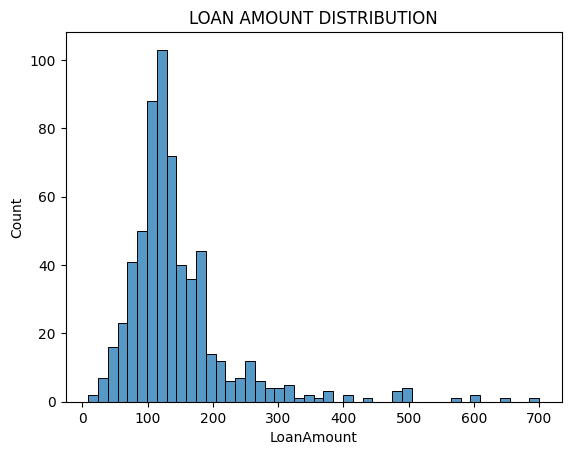

In [8]:
sns.histplot(data=df, x='LoanAmount')                  # defining variable to create histogram for loan amount distribution
plt.title('LOAN AMOUNT DISTRIBUTION')                  # assinging the title of the graph
plt.show()                                             # displaying the graph

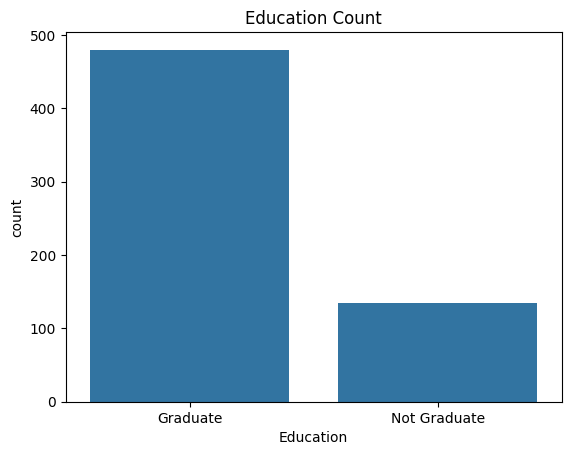

In [9]:
sns.countplot (data=df, x= 'Education')               # defining variable to ceate countplot for education distribution
plt.title('Education Count')                           # assinging the title of the graph
plt.show()                                            # Displaying the graph

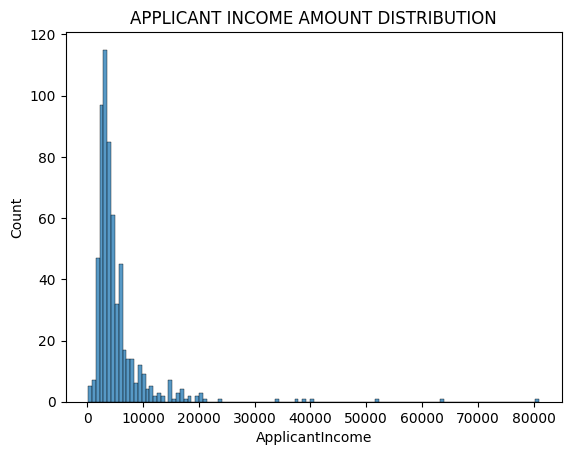

In [10]:
sns.histplot(data=df, x='ApplicantIncome')      # defining variable to create histogram for Applicant income distribution
plt.title('APPLICANT INCOME AMOUNT DISTRIBUTION')     # assinging the title of the graph
plt.show()                                            # displaying the graph

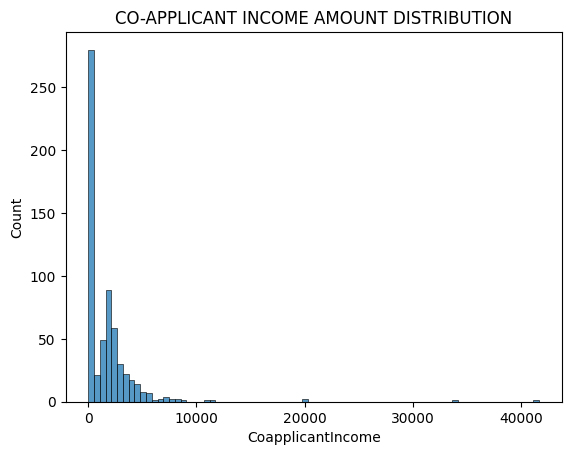

In [12]:
sns.histplot(data=df, x='CoapplicantIncome')      # defining variable to create histogram for Co-Applicant income distribution
plt.title('CO-APPLICANT INCOME AMOUNT DISTRIBUTION')     # assinging the title of the graph
plt.show()                                            # displaying the graph

In [13]:
from sklearn.preprocessing import LabelEncoder  # importing LabelEncoder to convert text columns to numbers
le = LabelEncoder()  # creating LabelEncoder object

In [18]:
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']  # defining categorical columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])  # transforming text values to numbers
    print(f"{col}: {le.classes_}")  # printing the classes of the column

Gender: [0 1]
Married: [0 1]
Dependents: [0 1 2 3]
Education: [0 1]
Self_Employed: [0 1]
Property_Area: [0 1 2]
Loan_Status: [0 1]


In [15]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [19]:
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)  # dropping columns not required for model training
y = df['Loan_Status']  # target column to predict

In [21]:
from sklearn.model_selection import train_test_split  # importing train_test_split to split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)       # splitting data into 80% train and 20% test

In [28]:
from sklearn.linear_model import LogisticRegression       # importing logistic regression to predict loan status
model = LogisticRegression(max_iter=5000)                              # creating logistic regression object

In [29]:
model.fit(X_train, y_train)   # training the model on training data


LogisticRegression(max_iter=5000)

In [30]:
y_pred = model.predict(X_test)            # predicting loan status on test data

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix  # importing metrics to evaluate model performance
print(accuracy_score(y_test, y_pred))  # displaying model accuracy

0.7886178861788617


In [32]:
print(confusion_matrix(y_test, y_pred))       # displaying confusion matrix to evaluate prediction results

[[18 25]
 [ 1 79]]


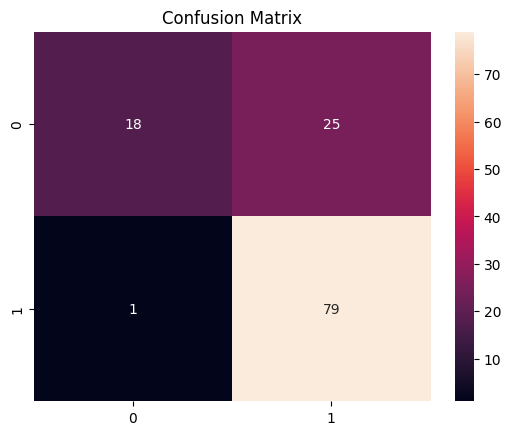

In [33]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')  # visualizing confusion matrix
plt.title('Confusion Matrix')  # title of the graph
plt.show()  # displaying the graph

In [35]:
feat_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})  # creating dataframe of feature importance
print(feat_importance.sort_values('Coefficient', ascending=False))  # sorting by importance

              Feature  Coefficient
9      Credit_History     3.281657
1             Married     0.595841
4       Self_Employed     0.124232
2          Dependents     0.109502
10      Property_Area     0.090150
8    Loan_Amount_Term     0.000611
5     ApplicantIncome    -0.000005
6   CoapplicantIncome    -0.000048
7          LoanAmount    -0.001932
0              Gender    -0.142372
3           Education    -0.358718
